In [19]:
import scanpy as sc
import pandas as pd
from pathlib import Path

In [20]:
# Paths & basic setup
adata_path = "/data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/sub_adata_microglia_leiden6_noOutside_reclustered_gatex2.h5ad"
adata = sc.read_h5ad(adata_path)

In [21]:
# Name of the clustering column in adata.obs
CLUSTER_COL_ADATA = "leiden_mg_gatex2_0.4"   # change if your cluster is named differently

# new column name
NEW_COL_NAME = "miranda_submggatex2_cell_type"

# Make sure clusters are strings for consistent mapping
adata.obs[CLUSTER_COL_ADATA] = adata.obs[CLUSTER_COL_ADATA].astype(str).str.strip()

print("Unique clusters in adata:", sorted(adata.obs[CLUSTER_COL_ADATA].unique()))

Unique clusters in adata: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [22]:
# Miranda mapping
cluster_to_type = {
    "0":  "Endothelial cell",
    "1":  "OPC",
    "2":  "Perivascular macrophages",
    "3":  "Spatial mixed cluster / multiplet: homeostatic microglia+interneuron",
    "4":  "Homeostatic microglia",
    "5":  "DAM microglia",
    "6":  "IFN-R microglia ",
    "7":  "Spatial mixed cluster / multiplet: homeostatic microglia + L2–L6 IT Glutamatergic neuron",
    "8":  "Spatial mixed cluster / multiplet: homeostatic microglia +  Pvalb GABAergic neuron",
    "9":  "Astrocyte"
}

# do we have any clusters in adata not covered by Miranda?
adata_clusters = set(adata.obs[CLUSTER_COL_ADATA].unique())
miranda_clusters = set(cluster_to_type.keys())

missing_in_miranda = adata_clusters - miranda_clusters
extra_in_miranda   = miranda_clusters - adata_clusters

print("Clusters in adata not in Miranda mapping:", missing_in_miranda)
print("Clusters in Miranda mapping not in adata:", extra_in_miranda)

Clusters in adata not in Miranda mapping: set()
Clusters in Miranda mapping not in adata: set()


In [23]:
# Attach annotations to adata.obs 
adata.obs[NEW_COL_NAME] = (
    adata.obs[CLUSTER_COL_ADATA]
        .map(cluster_to_type)
        .astype("category")
)

print(adata.obs[[CLUSTER_COL_ADATA, NEW_COL_NAME]].head())
print(adata.obs[NEW_COL_NAME].value_counts().to_frame(name='n_cells'))
print("Cells without a mapped type:",
      adata.obs[NEW_COL_NAME].isna().sum())

                      leiden_mg_gatex2_0.4  \
unique_cell_index                            
new_slide1_aaabbkeo-1                    0   
new_slide1_aaabegce-1                    7   
new_slide1_aaahghfl-1                    4   
new_slide1_aaajccdb-1                    3   
new_slide1_aaakeflk-1                    7   

                                           miranda_submggatex2_cell_type  
unique_cell_index                                                         
new_slide1_aaabbkeo-1                                   Endothelial cell  
new_slide1_aaabegce-1  Spatial mixed cluster / multiplet: homeostatic...  
new_slide1_aaahghfl-1                              Homeostatic microglia  
new_slide1_aaajccdb-1  Spatial mixed cluster / multiplet: homeostatic...  
new_slide1_aaakeflk-1  Spatial mixed cluster / multiplet: homeostatic...  
                                                    n_cells
miranda_submggatex2_cell_type                              
Spatial mixed cluster / multiple

In [24]:
# by cluster
table = (
adata.obs
.groupby([CLUSTER_COL_ADATA, NEW_COL_NAME])
.size()
.reset_index(name='n_cells')
)
pd.set_option("display.max_rows", None)
display(table)

/tmp/ipykernel_1077442/2349972790.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([CLUSTER_COL_ADATA, NEW_COL_NAME])


,leiden_mg_gatex2_0.4,miranda_submggatex2_cell_type,n_cells
0,0,Astrocyte,0
1,0,DAM microglia,0
2,0,Endothelial cell,2641
3,0,Homeostatic microglia,0
4,0,IFN-R microglia,0
5,0,OPC,0
6,0,Perivascular macrophages,0
7,0,Spatial mixed cluster / multiplet: homeostatic...,0
8,0,Spatial mixed cluster / multiplet: homeostatic...,0
9,0,Spatial mixed cluster / multiplet: homeostatic...,0


In [25]:
# Save updated AnnData 
out_h5ad = adata_path.replace(".h5ad", "_with_miranda.h5ad")
adata.write(out_h5ad)
print("Saved updated AnnData with Miranda annotations:", out_h5ad)

Saved updated AnnData with Miranda annotations: /data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/sub_adata_microglia_leiden6_noOutside_reclustered_gatex2_with_miranda.h5ad


In [27]:
import os
import pandas as pd
import scanpy as sc

adata_path = "/data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/sub_adata_microglia_leiden6_noOutside_reclustered_gatex2_with_miranda.h5ad"
out_dir = "/data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/results/"
os.makedirs(out_dir, exist_ok=True)

adata = sc.read_h5ad(adata_path)
obs = adata.obs.copy()

# Decide which column identifies slide/run
run_col = None
for c in ["run_key", "batch", "sample_id"]:
    if c in obs.columns:
        run_col = c
        break

if run_col is None:
    # fallback: infer run from obs_names like "new_slide1_12345"
    obs["__run__"] = pd.Index(obs.index).to_series().astype(str).str.split("_", n=1).str[0].values
    run_col = "__run__"

print("Using run column:", run_col)
print("Runs found:", obs[run_col].unique().tolist())

#    Make sure we have a cell_id column for Xenium Explorer
#    Important: Xenium usually wants the *original* cell_id per run,
#    not the namespaced one. We'll strip the "run_" prefix if present.
if "cell_id" in obs.columns:
    cell_id_series = obs["cell_id"].astype(str)
else:
    cell_id_series = pd.Index(obs.index).astype(str)

# If obs_names are like "new_slide1_12345", strip prefix to get "12345"
# (only strip if it looks like it starts with "<run>_")
def strip_prefix(cell_id, run):
    s = str(cell_id)
    pref = f"{run}_"
    return s[len(pref):] if s.startswith(pref) else s

# Export per run
required_col = NEW_COL_NAME ########################################################
if required_col not in obs.columns:
    raise ValueError(f"Missing '{required_col}' in adata.obs. Columns: {obs.columns.tolist()}")

for run in sorted(obs[run_col].astype(str).unique()):
    sub = obs[obs[run_col].astype(str) == run].copy()

    # build per-run cell_id
    sub_cell_id = (sub["cell_id"].astype(str) if "cell_id" in sub.columns else pd.Index(sub.index).astype(str))
    sub_cell_id = [strip_prefix(cid, run) for cid in sub_cell_id]

    export = pd.DataFrame({
        "cell_id": sub_cell_id,
        "group": sub[required_col].astype(str).values
    })

    out_path = os.path.join(out_dir, f"cell_groups_{NEW_COL_NAME}_{run}.csv")
    export.to_csv(out_path, index=False)
    print("Wrote:", out_path, "| rows:", export.shape[0])

Using run column: run_key
Runs found: ['new_slide1', 'new_slide2']
Wrote: /data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/results/cell_groups_miranda_submggatex2_cell_type_new_slide1.csv | rows: 31761
Wrote: /data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/results/cell_groups_miranda_submggatex2_cell_type_new_slide2.csv | rows: 26792


In [28]:
# Adding DAM vs. HOME

adata_path = "/data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/sub_adata_microglia_leiden6_noOutside_reclustered_gatex2_with_miranda.h5ad"
out_dir = "/data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/results/"
os.makedirs(out_dir, exist_ok=True)

adata = sc.read_h5ad(adata_path)
# Coarse state per microglia subcluster
cluster_to_state = {
    "0":  "non-microglial",
    "1":  "non-microglial",          
    "2":  "non-microglial",
    "3":  "Homeostatic",
    "4":  "Homeostatic",          
    "5":  "DAM",
    "6":  "DAM",
    "7":  "Homeostatic",
    "8":  "Homeostatic",
    "9":  "non-microglial"
}

adata.obs["mg_state_dam_home"] = (
    adata.obs[CLUSTER_COL_ADATA].astype(str).map(cluster_to_state).fillna("UNMAPPED_CLUSTER")
).astype("category")
print(adata.obs[[CLUSTER_COL_ADATA, "mg_state_dam_home"]].head())
print(adata.obs["mg_state_dam_home"].value_counts().to_frame(name='n_cells'))
print("Cells without a mapped type:",
      adata.obs["mg_state_dam_home"].isna().sum())

                      leiden_mg_gatex2_0.4 mg_state_dam_home
unique_cell_index                                           
new_slide1_aaabbkeo-1                    0    non-microglial
new_slide1_aaabegce-1                    7       Homeostatic
new_slide1_aaahghfl-1                    4       Homeostatic
new_slide1_aaajccdb-1                    3       Homeostatic
new_slide1_aaakeflk-1                    7       Homeostatic
                   n_cells
mg_state_dam_home         
Homeostatic          34101
DAM                  14433
non-microglial       10019
Cells without a mapped type: 0


In [29]:
adata.write("/data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/sub_adata_microglia_leiden6_noOutside_reclustered_gatex2_with_miranda_DAMvHOME.h5ad", compression="gzip")


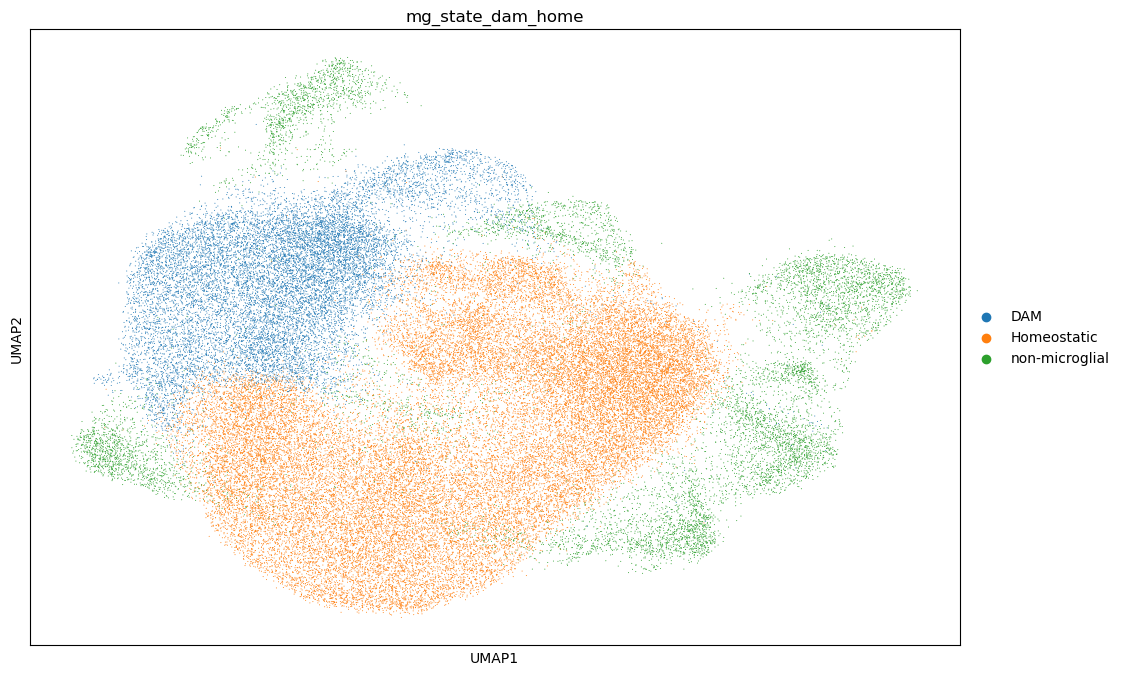

In [58]:
adata = sc.read_h5ad("/data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/sub_adata_microglia_leiden6_noOutside_reclustered_gatex2_with_miranda_DAMvHOME.h5ad")
fig = sc.pl.umap(
    adata,
    color="mg_state_dam_home",
    legend_loc="right margin",
    return_fig=True,
    wspace=0.4
)

fig.set_size_inches(12, 8)


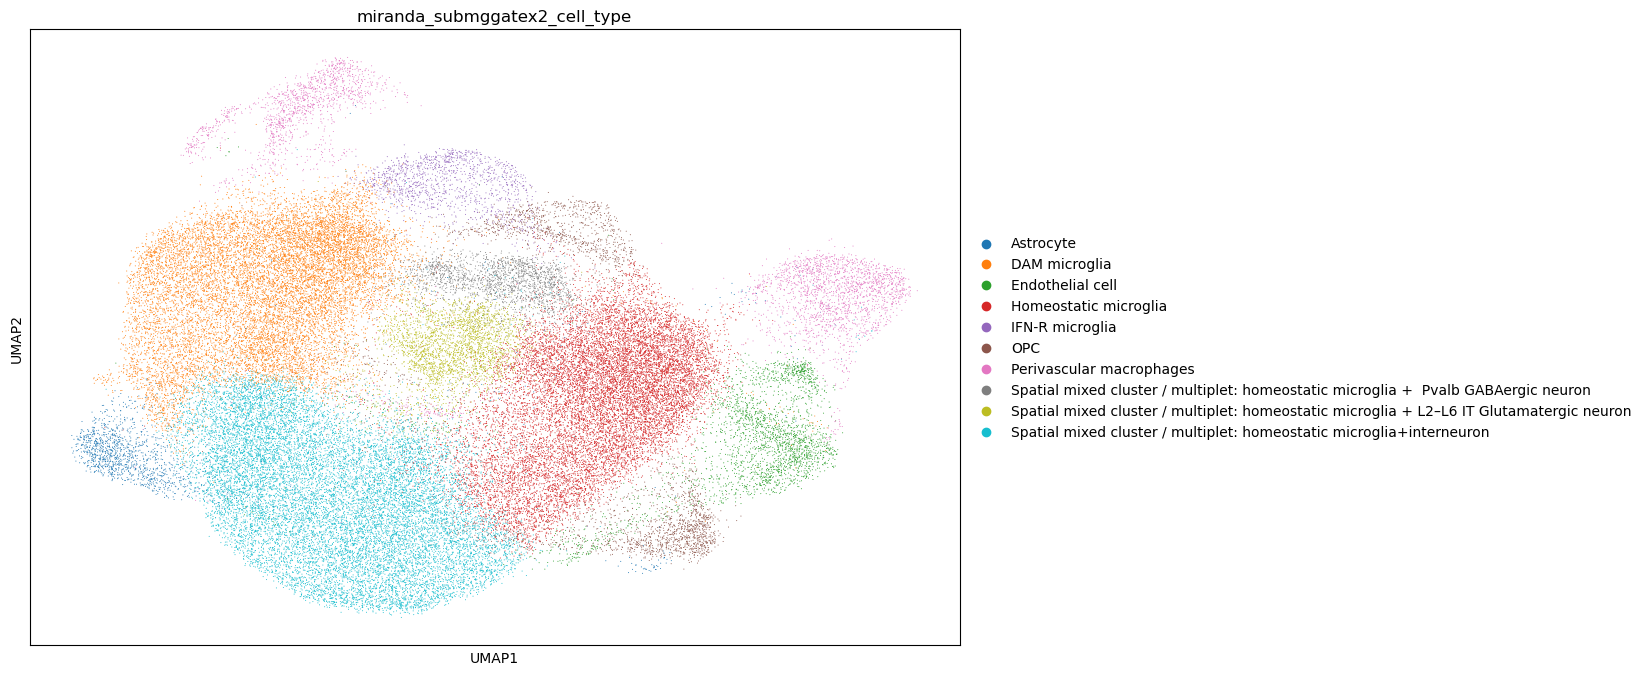

In [61]:
fig = sc.pl.umap(
    adata,
    color="miranda_submggatex2_cell_type",
    legend_loc="right margin",
    return_fig=True,
    wspace=0.4
)

fig.set_size_inches(12, 8)

# Analysis with Annotationed Subcluster

In [34]:
A_sub_pos = adata
cc = A_sub_pos.obs["condition_consol"].astype(str)
A_sub_pos.obs["genotype"] = cc.str.split("-").str[0]
A_sub_pos.obs["treatment"] = cc.str.split("-").str[1]

geno_tab = pd.crosstab(
    A_sub_pos.obs["genotype"],
    A_sub_pos.obs["mg_state_dam_home"],
    normalize="index"
)

# FAD only
fad = A_sub_pos[A_sub_pos.obs["genotype"] == "FAD"]
fad_tab = pd.crosstab(
    fad.obs["treatment"],
    fad.obs["mg_state_dam_home"],
    normalize="index"
)

# WT only
wt = A_sub_pos[A_sub_pos.obs["genotype"] == "WT"]
wt_tab = pd.crosstab(
    wt.obs["treatment"],
    wt.obs["mg_state_dam_home"],
    normalize="index"
)
print("FAD vs WT:")
display(geno_tab)

print("FAD (Abe vs Veh):")
display(fad_tab)

print("\nWT (Abe vs Veh):")
display(wt_tab)

FAD vs WT:


mg_state_dam_home,DAM,Homeostatic,non-microglial
genotype,,,
FAD,0.358788,0.498114,0.143097
WT,0.018232,0.753716,0.228052


FAD (Abe vs Veh):


mg_state_dam_home,DAM,Homeostatic,non-microglial
treatment,,,
Abe,0.362454,0.483254,0.154292
Veh,0.355584,0.511102,0.133314



WT (Abe vs Veh):


mg_state_dam_home,DAM,Homeostatic,non-microglial
treatment,,,
Abe,0.016321,0.750878,0.232801
Veh,0.019840,0.756105,0.224056


In [35]:
A_sub_pos = adata
cc = A_sub_pos.obs["condition_consol"].astype(str)
A_sub_pos.obs["genotype"] = cc.str.split("-").str[0]
A_sub_pos.obs["treatment"] = cc.str.split("-").str[1]

geno_tab = pd.crosstab(
    A_sub_pos.obs["genotype"],
    A_sub_pos.obs["miranda_submggatex2_cell_type"],
    normalize="index"
)

# FAD only
fad = A_sub_pos[A_sub_pos.obs["genotype"] == "FAD"]
fad_tab = pd.crosstab(
    fad.obs["treatment"],
    fad.obs["miranda_submggatex2_cell_type"],
    normalize="index"
)

# WT only
wt = A_sub_pos[A_sub_pos.obs["genotype"] == "WT"]
wt_tab = pd.crosstab(
    wt.obs["treatment"],
    wt.obs["miranda_submggatex2_cell_type"],
    normalize="index"
)
print("FAD vs WT:")
display(geno_tab)

print("FAD (Abe vs Veh):")
display(fad_tab)

print("\nWT (Abe vs Veh):")
display(wt_tab)

FAD vs WT:


miranda_submggatex2_cell_type,Astrocyte,DAM microglia,Endothelial cell,Homeostatic microglia,IFN-R microglia,OPC,Perivascular macrophages,Spatial mixed cluster / multiplet: homeostatic microglia + Pvalb GABAergic neuron,Spatial mixed cluster / multiplet: homeostatic microglia + L2–L6 IT Glutamatergic neuron,Spatial mixed cluster / multiplet: homeostatic microglia+interneuron
genotype,,,,,,,,,,
FAD,0.021888,0.330352,0.034322,0.151888,0.028436,0.043317,0.043571,0.032207,0.042348,0.271671
WT,0.030714,0.006578,0.067022,0.426270,0.011654,0.041384,0.088931,0.036774,0.057130,0.233542


FAD (Abe vs Veh):


miranda_submggatex2_cell_type,Astrocyte,DAM microglia,Endothelial cell,Homeostatic microglia,IFN-R microglia,OPC,Perivascular macrophages,Spatial mixed cluster / multiplet: homeostatic microglia + Pvalb GABAergic neuron,Spatial mixed cluster / multiplet: homeostatic microglia + L2–L6 IT Glutamatergic neuron,Spatial mixed cluster / multiplet: homeostatic microglia+interneuron
treatment,,,,,,,,,,
Abe,0.025952,0.324155,0.033219,0.137628,0.038300,0.044200,0.050921,0.030869,0.039939,0.274818
Veh,0.018335,0.335769,0.035286,0.164351,0.019816,0.042544,0.037148,0.033376,0.044454,0.268920



WT (Abe vs Veh):


miranda_submggatex2_cell_type,Astrocyte,DAM microglia,Endothelial cell,Homeostatic microglia,IFN-R microglia,OPC,Perivascular macrophages,Spatial mixed cluster / multiplet: homeostatic microglia + Pvalb GABAergic neuron,Spatial mixed cluster / multiplet: homeostatic microglia + L2–L6 IT Glutamatergic neuron,Spatial mixed cluster / multiplet: homeostatic microglia+interneuron
treatment,,,,,,,,,,
Abe,0.030488,0.005894,0.080245,0.407798,0.010427,0.043409,0.078658,0.037742,0.069704,0.235634
Veh,0.030904,0.007154,0.055895,0.441816,0.012686,0.039680,0.097577,0.035960,0.046547,0.231782


In [50]:
import os
import re
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

# ---------------------------
# LOAD
# ---------------------------
adata = sc.read_h5ad(
    "/data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/"
    "sub_adata_microglia_leiden6_noOutside_reclustered_gatex2_with_miranda_DAMvHOME.h5ad"
)

OUT_DIR = "/data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/results/boxplots_ALLgenes_state_condition_replicateMeans"
os.makedirs(OUT_DIR, exist_ok=True)

STATE_COL = "mg_state_dam_home"     # DAM / Homeostatic / non-microglial
COND_COL  = "condition"             # genotype-treatment{number} (e.g. WT-V3)
RUN_COL   = "run_key"               # slide id
LAYER     = "log1p"                 # IMPORTANT

state_order = ["DAM", "Homeostatic"]
cond_order  = ["WT-Veh", "WT-Abe", "FAD-Veh", "FAD-Abe"]  # for legend order

# ---------------------------
# SANITY
# ---------------------------
assert LAYER in adata.layers, f"Missing adata.layers['{LAYER}']"
assert STATE_COL in adata.obs, f"Missing obs column: {STATE_COL}"
assert COND_COL in adata.obs, f"Missing obs column: {COND_COL}"
assert RUN_COL in adata.obs, f"Missing obs column: {RUN_COL}"

# ---------------------------
# FIX condition: overwrite WT-V3 -> WT-Veh3 (and WT-V{digit} -> WT-Veh{digit})
# - This handles WT-V3, WT-V1, WT-V12, etc.
# - Only affects WT-V*, per your request.
# ---------------------------
cond = adata.obs[COND_COL].astype(str)

# Replace "WT-V" followed by digits with "WT-Veh" + digits
cond_fixed = cond.str.replace(r"^WT-V(\d+)$", r"WT-Veh\1", regex=True)

# (Optional) if you also have things like WT-V3_something, you could broaden:
# cond_fixed = cond_fixed.str.replace(r"^WT-V(\d+)(.*)$", r"WT-Veh\1\2", regex=True)

adata.obs[COND_COL] = cond_fixed

# ---------------------------
# Build condition_consol by stripping trailing digits
# e.g., WT-Veh3 -> WT-Veh ; FAD-Abe2 -> FAD-Abe
# ---------------------------
adata.obs["condition_consol"] = adata.obs[COND_COL].astype(str).str.replace(r"\d+$", "", regex=True)

# ---------------------------
# FILTER to DAM/Homeostatic only
# ---------------------------
adata2 = adata[adata.obs[STATE_COL].isin(state_order)].copy()

adata2.obs[STATE_COL] = pd.Categorical(
    adata2.obs[STATE_COL].astype(str),
    categories=state_order,
    ordered=True
)

# keep only conditions that actually exist, in a stable order
present_conds = [c for c in cond_order if c in set(adata2.obs["condition_consol"].astype(str))]
# plus any unexpected labels (append at end)
extras = sorted(set(adata2.obs["condition_consol"].astype(str)) - set(present_conds))
present_conds = present_conds + extras

adata2.obs["condition_consol"] = pd.Categorical(
    adata2.obs["condition_consol"].astype(str),
    categories=present_conds,
    ordered=True
)

# ---------------------------
# helper: get 1 gene vector from sparse/dense
# ---------------------------
def get_gene_expr(adata_obj, gene, layer=LAYER):
    X = adata_obj[:, gene].layers[layer]  # n_obs x 1
    if sp.issparse(X):
        return np.asarray(X.toarray()).ravel()
    return np.asarray(X).ravel()

# ---------------------------
# LOOP OVER ALL GENES
# Boxes: per-cell log1p
# Points: replicate mean per (run_key × condition_consol × state)
# Diamonds: mean of replicate means per (condition_consol × state)
# Lines: connect diamonds DAM<->Homeostatic within each condition_consol
# ---------------------------
genes = adata2.var_names.to_list()
print("Plotting genes:", len(genes))
print("Conditions (condition_consol):", present_conds)

base_obs = adata2.obs[[STATE_COL, "condition_consol", RUN_COL]].copy()

for i, gene in enumerate(genes, start=1):
    expr = get_gene_expr(adata2, gene, layer=LAYER)

    df = base_obs.copy()
    df["expr"] = expr

    # Replicate unit = (run_key × condition_consol)
    # Compute replicate means within each (replicate × state)
    df_rep_means = (
        df.groupby([RUN_COL, "condition_consol", STATE_COL], observed=True)["expr"]
          .mean()
          .reset_index()
          .rename(columns={"expr": "rep_mean"})
    )

    # Mean across replicates within each (condition_consol × state)
    df_cond_means = (
        df_rep_means.groupby(["condition_consol", STATE_COL], observed=True)["rep_mean"]
          .mean()
          .reset_index()
          .rename(columns={"rep_mean": "mean_of_reps"})
    )

    plt.figure(figsize=(8.2, 5.2))

    # 1) Cell-level boxes
    ax = sns.boxplot(
        data=df,
        x=STATE_COL,
        y="expr",
        hue="condition_consol",
        order=state_order,
        hue_order=present_conds,
        fliersize=0
    )

    # 2) Replicate mean points (one per run_key×condition_consol×state)
    sns.stripplot(
        data=df_rep_means,
        x=STATE_COL,
        y="rep_mean",
        hue="condition_consol",
        order=state_order,
        hue_order=present_conds,
        dodge=True,
        jitter=0.10,
        size=3,
        alpha=0.80,
        linewidth=0,
        ax=ax
    )

    # 3) Condition mean across replicates (big diamonds)
    sns.stripplot(
        data=df_cond_means,
        x=STATE_COL,
        y="mean_of_reps",
        hue="condition_consol",
        order=state_order,
        hue_order=present_conds,
        dodge=True,
        marker="D",
        size=8,
        edgecolor="black",
        linewidth=1,
        ax=ax
    )

    # 4) Connect condition-level means DAM ↔ Homeostatic
    if len(state_order) == 2 and len(present_conds) > 0:
        n_hue = len(present_conds)
        span = 0.8
        step = span / n_hue
        offsets = {cond: (-span/2 + (j + 0.5)*step) for j, cond in enumerate(present_conds)}

        pivot = df_cond_means.pivot_table(
            index="condition_consol",
            columns=STATE_COL,
            values="mean_of_reps",
            observed=True
        )

        for cond_name in present_conds:
            if cond_name not in pivot.index:
                continue
            y0 = pivot.loc[cond_name, state_order[0]]
            y1 = pivot.loc[cond_name, state_order[1]]
            if pd.isna(y0) or pd.isna(y1):
                continue

            x0 = 0 + offsets[cond_name]
            x1 = 1 + offsets[cond_name]
            ax.plot([x0, x1], [y0, y1], linewidth=2, alpha=0.9)

    ax.set_title(
        f"{gene} (log1p) by state and condition\n"
        f"boxes=cells; dots=mean per (run_key×condition); diamonds=mean across replicates"
    )
    ax.set_xlabel("Microglia state")
    ax.set_ylabel("log1p expression")

    # legend cleanup (we added hue 3x)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:len(present_conds)],
        labels[:len(present_conds)],
        title="Condition",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()

    out_png = os.path.join(OUT_DIR, f"{i:03d}_box_{gene}_repMeans.png")
    plt.savefig(out_png, dpi=200)
    plt.close()

    if i % 25 == 0:
        print(f"...{i}/{len(genes)} done")

print("Done. Wrote plots to:", OUT_DIR)

Plotting genes: 347
Conditions (condition_consol): ['WT-Veh', 'WT-Abe', 'FAD-Veh', 'FAD-Abe']
...25/347 done
...50/347 done
...75/347 done
...100/347 done
...125/347 done
...150/347 done
...175/347 done
...200/347 done
...225/347 done
...250/347 done
...275/347 done
...300/347 done
...325/347 done
Done. Wrote plots to: /data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/results/boxplots_ALLgenes_state_condition_replicateMeans


In [130]:
# STEP 0 — Imports + paths + settings
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from matplotlib.backends.backend_pdf import PdfPages

# Annotated subcluster (your working object)
SUB_PATH = (
    "/data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/"
    "sub_adata_microglia_leiden6_noOutside_reclustered_gatex2_with_miranda_DAMvHOME.h5ad"
)

# Whole/precluster Xenium object (source of raw counts)
PRE_PATH = "/data/projects/oscar/Miranda/results/adata_consol_newslides_qc_filter_protectmicroglia.h5ad"

OUT_DIR = (
    "/data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/results/"
    "geneCounts_mouseMeans_boxplots"
)
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PDF       = os.path.join(OUT_DIR, "ALLgenes_countsPerCell_mouseMeans.pdf")
OUT_MOUSE_CSV = os.path.join(OUT_DIR, "ALLgenes_mouseMeans_long.csv")
OUT_GROUP_CSV = os.path.join(OUT_DIR, "ALLgenes_groupMeans_long.csv")

# Column names
CELLTYPE_COL  = "miranda_submggatex2_cell_type"
COND_COL      = "condition"
COND_CONSOL   = "condition_consol"   # already exists in your adata
RUN_COL       = "run_key"            # optional, not used for grouping

# New columns we will create/use
REPL_COL      = "condition_rep"      # mouse ID label (digits kept), WT-V# fixed to WT-Veh#
NEW_STATE_COL = "DAM_IFN_HOME"       # HOME/DAM/IFN-R from miranda_submggatex2_cell_type

# Layer for raw counts (we will attach as adata.layers['counts'])
COUNTS_LAYER  = "counts"

# Orders
cond_order  = ["FAD-Abe", "FAD-Veh", "WT-Abe", "WT-Veh" ]
state_order = ["DAM", "IFN-R", "HOME"]
keep_states = set(state_order)       # drop OTHER:* contaminants

In [131]:
# ============================================================
# STEP 1 — Load adata (subcluster) + pre (whole)
# ============================================================
adata = sc.read_h5ad(SUB_PATH)
pre   = sc.read_h5ad(PRE_PATH)

print("Loaded adata:", adata.shape)
print("Loaded pre  :", pre.shape)

print("Has condition_consol?", COND_CONSOL in adata.obs.columns)
print("Has run_key?", RUN_COL in adata.obs.columns)

print("pre.layers keys:", list(pre.layers.keys())[:40])
print("adata.layers keys:", list(adata.layers.keys()))
print("adata.raw is None?", adata.raw is None)
print("pre.raw is None?", pre.raw is None)

Loaded adata: (58553, 347)
Loaded pre  : (948614, 347)
Has condition_consol? True
Has run_key? True
pre.layers keys: []
adata.layers keys: ['log1p']
adata.raw is None? True
pre.raw is None? True


In [132]:
# STEP 2 — Attach RAW COUNTS from pre -> adata.layers['counts']
# Priority:
#   1) pre.layers['counts']
#   2) pre.X (ONLY if you confirm it is raw counts)
if "counts" in pre.layers:
    counts_src = "pre.layers['counts']"
else:
    counts_src = "pre.X (VERIFY this is raw counts!)"

print("Counts source selected:", counts_src)

missing = adata.obs_names.difference(pre.obs_names)
if len(missing) > 0:
    raise RuntimeError(
        f"{len(missing)} cells in adata not found in pre by obs_names.\n"
        f"Example missing: {list(missing[:5])}"
    )

# Align cells
pre_aligned = pre[adata.obs_names, :].copy()

# Align genes (errors if missing)
if not np.array_equal(pre_aligned.var_names, adata.var_names):
    pre_aligned = pre_aligned[:, adata.var_names].copy()

# Extract aligned counts
if "counts" in pre.layers:
    counts_aligned = pre_aligned.layers["counts"]
else:
    counts_aligned = pre_aligned.X

adata.layers[COUNTS_LAYER] = counts_aligned.copy()

print("Attached adata.layers['counts']:", adata.layers[COUNTS_LAYER].shape, "| source:", counts_src)

# Quick integer-ish sanity check
Xc = adata.layers[COUNTS_LAYER]
vals = Xc.data[:20] if sp.issparse(Xc) else np.ravel(Xc)[:20]
print("counts sample:", vals)
print("near-integers?", np.allclose(vals, np.round(vals)))

Counts source selected: pre.X (VERIFY this is raw counts!)
Attached adata.layers['counts']: (58553, 347) | source: pre.X (VERIFY this is raw counts!)
counts sample: [ 1.  1.  1.  2.  1.  2.  3.  1.  1.  1. 10. 24.  1.  2.  5.  1.  1.  1.
  6.  2.]
near-integers? True


In [133]:
# STEP 3 — Create condition_rep (mouse ID) from condition
# Dot = mean per mouse, so replicate ID = condition name (digits kept),
# combining both brain sections automatically.
# Fix WT-V3 -> WT-Veh3 in the mouse ID label.
assert COND_COL in adata.obs, f"Missing {COND_COL}"
assert COND_CONSOL in adata.obs, f"Missing existing {COND_CONSOL}"

cond = adata.obs[COND_COL].astype(str)
adata.obs[REPL_COL] = cond.str.replace(r"^WT-V(\d+)$", r"WT-Veh\1", regex=True)

print("Example condition -> condition_rep:")
print(pd.DataFrame({"condition": cond.head(8).values, "condition_rep": adata.obs[REPL_COL].head(8).values}))

# Optional sanity: show # brain sections per mouse
if RUN_COL in adata.obs:
    sec_counts = (
        adata.obs[[REPL_COL, RUN_COL]]
        .drop_duplicates()
        .groupby(REPL_COL)[RUN_COL]
        .nunique()
        .sort_values(ascending=False)
    )
    print("\n# unique run_key (brain sections) per mouse (condition_rep):")
    print(sec_counts.head(30))

Example condition -> condition_rep:
  condition condition_rep
0  FAD-Abe3      FAD-Abe3
1  FAD-Abe3      FAD-Abe3
2  FAD-Abe3      FAD-Abe3
3  FAD-Abe3      FAD-Abe3
4  FAD-Abe3      FAD-Abe3
5  FAD-Abe3      FAD-Abe3
6  FAD-Abe3      FAD-Abe3
7  FAD-Abe3      FAD-Abe3

# unique run_key (brain sections) per mouse (condition_rep):
condition_rep
WT-Abe2     2
WT-Veh2     2
FAD-Veh2    2
FAD-Abe1    1
FAD-Veh1    1
FAD-Abe3    1
FAD-Abe2    1
FAD-Veh3    1
WT-Abe1     1
WT-Abe3     1
WT-Veh1     1
WT-Veh3     1
Name: run_key, dtype: int64


In [134]:
# STEP 4 — Create DAM_IFN_HOME FROM miranda_submggatex2_cell_type ONLY
#   - IFN-R_microglia    -> IFN-R
#   - DAM_microglia      -> DAM
#   - *homeostatic* ...  -> HOME
#   - anything else      -> OTHER:<label>  (will be excluded from plots)
assert CELLTYPE_COL in adata.obs, f"Missing {CELLTYPE_COL}"

ct = adata.obs[CELLTYPE_COL].astype(str)

is_ifn  = ct.str.contains(r"IFN", case=False, regex=True)
is_dam  = ct.str.contains(r"\bDAM\b", case=False, regex=True)
is_home = ct.str.contains(r"homeostatic", case=False, regex=True)

adata.obs[NEW_STATE_COL] = "OTHER:" + ct
adata.obs.loc[is_home, NEW_STATE_COL] = "HOME"
adata.obs.loc[is_dam,  NEW_STATE_COL] = "DAM"
adata.obs.loc[is_ifn,  NEW_STATE_COL] = "IFN-R"  # precedence

print("DAM_IFN_HOME counts:")
print(adata.obs[NEW_STATE_COL].value_counts())

other_labels = ct[adata.obs[NEW_STATE_COL].astype(str).str.startswith("OTHER:")].value_counts()
if len(other_labels) > 0:
    print("\nLabels not matched to DAM/IFN/homeostatic (please inspect):")
    print(other_labels)

DAM_IFN_HOME counts:
DAM_IFN_HOME
HOME                              34101
DAM                               13092
OTHER:Perivascular macrophages     3427
OTHER:Endothelial cell             2641
OTHER:OPC                          2499
OTHER:Astrocyte                    1452
IFN-R                              1341
Name: count, dtype: int64

Labels not matched to DAM/IFN/homeostatic (please inspect):
miranda_submggatex2_cell_type
Perivascular macrophages    3427
Endothelial cell            2641
OPC                         2499
Astrocyte                   1452
Name: count, dtype: int64


In [135]:
# STEP 5 — Set stable plotting order + build microglia-only base_obs
# stable condition order (only those present)
present_conds = [c for c in cond_order if c in set(adata.obs[COND_CONSOL].astype(str))]
extras = sorted(set(adata.obs[COND_CONSOL].astype(str)) - set(present_conds))
present_conds = present_conds + extras
print("present_conds:", present_conds)

base_obs = adata.obs[[NEW_STATE_COL, COND_CONSOL, REPL_COL]].copy()
base_obs[NEW_STATE_COL] = base_obs[NEW_STATE_COL].astype(str)
base_obs[COND_CONSOL]   = base_obs[COND_CONSOL].astype(str)

# microglia-only filter (HOME/DAM/IFN-R), drop OTHER:*
mask = base_obs[NEW_STATE_COL].isin(keep_states)
base_obs = base_obs.loc[mask].copy()

# apply categorical orders for stable plotting
base_obs[NEW_STATE_COL] = pd.Categorical(base_obs[NEW_STATE_COL], categories=state_order, ordered=True)
base_obs[COND_CONSOL]   = pd.Categorical(base_obs[COND_CONSOL], categories=present_conds, ordered=True)

print("Cells kept for plotting:", base_obs.shape[0])
print("State counts:\n", base_obs[NEW_STATE_COL].value_counts(dropna=False))

present_conds: ['FAD-Abe', 'FAD-Veh', 'WT-Abe', 'WT-Veh']
Cells kept for plotting: 48534
State counts:
 DAM_IFN_HOME
HOME     34101
DAM      13092
IFN-R     1341
Name: count, dtype: int64


In [136]:
# STEP 6 — Helper to extract one gene’s raw counts vector (per cell)
def get_gene_counts(adata_obj, gene, layer=COUNTS_LAYER):
    X = adata_obj[:, gene].layers[layer]  # n_cells x 1
    if sp.issparse(X):
        return np.asarray(X.toarray()).ravel()
    return np.asarray(X).ravel()

In [137]:
# STEP 7 — Loop genes (CONSISTENT 4-condition spacing everywhere):
#   - Boxplots are mouse means per condition × state
#   - Black dots are mouse means
#   - Diamonds are mean across mice
#   - DAM: WT conditions are present as categories but set to NaN (blank)
#   - Y-axis limited to replicate-mean range
from matplotlib.patches import Patch

genes = adata.var_names.to_list()
print("n_genes:", len(genes))
print("Writing PDF:", OUT_PDF)

all_mouse_means = []
all_group_means = []

# --- Put your exact hex codes here ---
cond_palette = {
    "FAD-Abe": "#1f77b4",
    "FAD-Veh": "#ff7f0e",
    "WT-Abe":  "#2ca02c",
    "WT-Veh":  "#d62728",
}

# stable condition order (only those present)
present_conds = [c for c in cond_order if c in set(adata.obs[COND_CONSOL].astype(str))]
extras = sorted(set(adata.obs[COND_CONSOL].astype(str)) - set(present_conds))
present_conds = present_conds + extras
print("present_conds:", present_conds)

box_palette_all   = {c: cond_palette.get(c, "#808080") for c in present_conds}
black_palette_all = {c: "black" for c in present_conds}

wt_conds = {"WT-Veh", "WT-Abe"}  # blank these in DAM only

with PdfPages(OUT_PDF) as pdf:
    for i, gene in enumerate(genes, start=1):
        expr_full = get_gene_counts(adata, gene, layer=COUNTS_LAYER)

        # Per-cell df (only used to compute mouse means)
        df = base_obs.copy()
        idx = adata.obs_names.get_indexer(df.index)
        df["expr"] = expr_full[idx]

        # mouse mean per (condition_consol × condition_rep × state)
        df_mouse = (
            df.groupby([COND_CONSOL, REPL_COL, NEW_STATE_COL], observed=True)["expr"]
              .agg(mouse_mean="mean", n_cells="size")
              .reset_index()
        )
        df_mouse["gene"] = gene
        all_mouse_means.append(df_mouse)

        # mean across mice per (condition_consol × state)
        df_group = (
            df_mouse.groupby([COND_CONSOL, NEW_STATE_COL], observed=True)["mouse_mean"]
                   .agg(mean_of_mice="mean", n_mice="count")
                   .reset_index()
        )
        df_group["gene"] = gene
        all_group_means.append(df_group)

        # --- IMPORTANT: make WT in DAM "blank" by setting values to NaN ---
        dam_wt_mask = (
            (df_mouse[NEW_STATE_COL].astype(str) == "DAM") &
            (df_mouse[COND_CONSOL].astype(str).isin(wt_conds))
        )
        df_mouse_plot = df_mouse.copy()
        df_mouse_plot.loc[dam_wt_mask, "mouse_mean"] = np.nan

        dam_wt_mask_g = (
            (df_group[NEW_STATE_COL].astype(str) == "DAM") &
            (df_group[COND_CONSOL].astype(str).isin(wt_conds))
        )
        df_group_plot = df_group.copy()
        df_group_plot.loc[dam_wt_mask_g, "mean_of_mice"] = np.nan

        # ---------------------------
        # PLOT (single pass; consistent spacing)
        # ---------------------------
        plt.figure(figsize=(9.0, 5.2))

        # 1) Boxplots from mouse means (replicates)
        ax = sns.boxplot(
            data=df_mouse_plot,
            x=NEW_STATE_COL,
            y="mouse_mean",
            hue=COND_CONSOL,
            order=state_order,
            hue_order=present_conds,
            fliersize=0,
            palette=box_palette_all
        )

        # 2) Mouse mean dots in BLACK
        sns.stripplot(
            data=df_mouse_plot,
            x=NEW_STATE_COL,
            y="mouse_mean",
            hue=COND_CONSOL,
            order=state_order,
            hue_order=present_conds,
            dodge=True,
            jitter=0.12,
            size=6,
            alpha=0.95,
            linewidth=0,
            palette=black_palette_all,
            ax=ax
        )

        # 3) Mean of mice (diamonds)
        sns.stripplot(
            data=df_group_plot,
            x=NEW_STATE_COL,
            y="mean_of_mice",
            hue=COND_CONSOL,
            order=state_order,
            hue_order=present_conds,
            dodge=True,
            marker="D",
            size=8,
            edgecolor="black",
            linewidth=1,
            palette=box_palette_all,
            ax=ax
        )

        # Y-axis limited to replicate means (and diamonds), ignoring NaNs
        ymax = max(
            float(np.nanmax(df_mouse_plot["mouse_mean"].values)) if len(df_mouse_plot) else 0.0,
            float(np.nanmax(df_group_plot["mean_of_mice"].values)) if len(df_group_plot) else 0.0
        )
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 0.25
        ax.set_ylim(0, ymax * 1.1)

        ax.set_title(
            f"{gene} (raw counts per cell)\n"
            f"box=mouse means; black dots=mouse means; diamonds=mean across mice"
        )
        ax.set_xlabel("")
        ax.set_ylabel("Mean transcripts per cell (per mouse; raw counts)")

        # Clean legend (avoid duplicates from multiple seaborn calls)
        legend_handles = [Patch(facecolor=box_palette_all[c], edgecolor="black", label=c) for c in present_conds]
        ax.legend(
            handles=legend_handles,
            title="Condition",
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

        plt.tight_layout()
        pdf.savefig(ax.figure, dpi=200)
        plt.close()

        if i % 50 == 0:
            print(f"...{i}/{len(genes)} pages written")

print("Finished PDF:", OUT_PDF)

n_genes: 347
Writing PDF: /data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/results/geneCounts_mouseMeans_boxplots/ALLgenes_countsPerCell_mouseMeans.pdf
present_conds: ['FAD-Abe', 'FAD-Veh', 'WT-Abe', 'WT-Veh']
...50/347 pages written
...100/347 pages written
...150/347 pages written
...200/347 pages written
...250/347 pages written
...300/347 pages written
Finished PDF: /data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/results/geneCounts_mouseMeans_boxplots/ALLgenes_countsPerCell_mouseMeans.pdf


In [138]:
# STEP 8 — Export long tables to CSV
#   - mouse_means_long: one row per (gene × condition_consol × condition_rep × state)
#   - group_means_long: one row per (gene × condition_consol × state) with mean across mice
mouse_means_long = pd.concat(all_mouse_means, ignore_index=True)
group_means_long = pd.concat(all_group_means, ignore_index=True)

mouse_means_long.to_csv(OUT_MOUSE_CSV, index=False)
group_means_long.to_csv(OUT_GROUP_CSV, index=False)

print("Wrote mouse means:", OUT_MOUSE_CSV)
print("Wrote group means:", OUT_GROUP_CSV)
print("Done.")

Wrote mouse means: /data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/results/geneCounts_mouseMeans_boxplots/ALLgenes_mouseMeans_long.csv
Wrote group means: /data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/results/geneCounts_mouseMeans_boxplots/ALLgenes_groupMeans_long.csv
Done.


## Save DAM, IFN, and HOME added column object

In [139]:
adata.write_h5ad(
    "/data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/"
    "sub_adata_microglia_leiden6_noOutside_reclustered_gatex2_with_miranda_DAMvHOME_damifnhome.h5ad", compression='gzip')

In [141]:
# Within each microglial state/annotation,
# compute p-values BETWEEN conditions using mouse-level mean TPCs
# (no multiple-testing adjustment; raw p-values only)
#
# Requires mouse_means_long with columns:
#   gene, mouse_mean, condition_consol, condition_rep, DAM_IFN_HOME
# If you don't have mouse_means_long in memory, it will read OUT_MOUSE_CSV.
import os
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

STATE_COL = NEW_STATE_COL      # "DAM_IFN_HOME"
COND_COL2 = COND_CONSOL        # "condition_consol"
MOUSE_COL = REPL_COL           # "condition_rep"

# Load mouse-level means if not already in memory
try:
    mouse_means_long
except NameError:
    mouse_means_long = pd.read_csv(OUT_MOUSE_CSV)

# Keep only the microglial annotations/states
states_keep = ["HOME", "DAM", "IFN-R"]
df = mouse_means_long.copy()
df[STATE_COL] = df[STATE_COL].astype(str)
df[COND_COL2] = df[COND_COL2].astype(str)
df = df[df[STATE_COL].isin(states_keep)].copy()

# Define the condition comparisons you want
comparisons = [
    ("FAD-Veh", "FAD-Abe", "FAD-Veh_vs_FAD-Abe"),
    ("WT-Veh",  "WT-Abe",  "WT-Veh_vs_WT-Abe"),
    ("WT-Veh",  "FAD-Veh", "WT-Veh_vs_FAD-Veh"),
    # add more if needed:
    # ("WT-Abe", "FAD-Abe", "WT-Abe_vs_FAD-Abe"),
]

rows = []
for (gene, state), sub in df.groupby(["gene", STATE_COL], observed=True):
    for a, b, comp_name in comparisons:
        xa = sub.loc[sub[COND_COL2] == a, "mouse_mean"].dropna().to_numpy()
        xb = sub.loc[sub[COND_COL2] == b, "mouse_mean"].dropna().to_numpy()

        # Mann–Whitney U, two-sided (mouse-level replication)
        if len(xa) == 0 or len(xb) == 0:
            p = np.nan
            stat = np.nan
        else:
            stat, p = mannwhitneyu(xa, xb, alternative="two-sided")

        rows.append({
            "gene": gene,
            "state": state,
            "comparison": comp_name,
            "groupA": a,
            "groupB": b,
            "nA": int(len(xa)),
            "nB": int(len(xb)),
            "meanA": float(np.mean(xa)) if len(xa) else np.nan,
            "meanB": float(np.mean(xb)) if len(xb) else np.nan,
            "U_stat": float(stat) if np.isfinite(stat) else np.nan,
            "p_value": float(p) if np.isfinite(p) else np.nan,
        })

pvals_long = pd.DataFrame(rows)

# Save long p-values table
OUT_PVALS = os.path.join(OUT_DIR, "ALLgenes_pvalues_mouseMeans_withinState_raw.csv")
pvals_long.to_csv(OUT_PVALS, index=False)
print("Wrote p-values table:", OUT_PVALS)
print(pvals_long.head(12))

# ------------------------------------------------------------
# OPTIONAL: also create a single wide table per gene×state
# that includes mean TPC per condition + p-values
# (uses group_means_long if available; otherwise reads OUT_GROUP_CSV)
# ------------------------------------------------------------
try:
    group_means_long
except NameError:
    group_means_long = pd.read_csv(OUT_GROUP_CSV)

means = group_means_long.copy()
means = means.rename(columns={STATE_COL: "state", COND_COL2: "condition", "mean_of_mice": "mean_TPC"})

means_wide = (
    means[means["state"].isin(states_keep)]
    .pivot_table(index=["gene", "state"], columns="condition", values="mean_TPC", aggfunc="first")
    .reset_index()
)
means_wide.columns = ["gene", "state"] + [f"mean_{c}" for c in means_wide.columns[2:]]

pvals_wide = (
    pvals_long.pivot_table(index=["gene", "state"], columns="comparison", values="p_value", aggfunc="first")
    .reset_index()
)
pvals_wide.columns = ["gene", "state"] + [f"p_{c}" for c in pvals_wide.columns[2:]]

final_wide = means_wide.merge(pvals_wide, on=["gene", "state"], how="left")

OUT_FINAL = os.path.join(OUT_DIR, "ALLgenes_meanTPC_plus_pvalues_withinState_raw.csv")
final_wide.to_csv(OUT_FINAL, index=False)
print("Wrote combined mean+pvalue table:", OUT_FINAL)
print(final_wide.head())

Wrote p-values table: /data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/results/geneCounts_mouseMeans_boxplots/ALLgenes_pvalues_mouseMeans_withinState_raw.csv
             gene  state          comparison   groupA   groupB  nA  nB  \
0   2010300C02Rik    DAM  FAD-Veh_vs_FAD-Abe  FAD-Veh  FAD-Abe   3   3   
1   2010300C02Rik    DAM    WT-Veh_vs_WT-Abe   WT-Veh   WT-Abe   3   3   
2   2010300C02Rik    DAM   WT-Veh_vs_FAD-Veh   WT-Veh  FAD-Veh   3   3   
3   2010300C02Rik   HOME  FAD-Veh_vs_FAD-Abe  FAD-Veh  FAD-Abe   3   3   
4   2010300C02Rik   HOME    WT-Veh_vs_WT-Abe   WT-Veh   WT-Abe   3   3   
5   2010300C02Rik   HOME   WT-Veh_vs_FAD-Veh   WT-Veh  FAD-Veh   3   3   
6   2010300C02Rik  IFN-R  FAD-Veh_vs_FAD-Abe  FAD-Veh  FAD-Abe   3   3   
7   2010300C02Rik  IFN-R    WT-Veh_vs_WT-Abe   WT-Veh   WT-Abe   3   3   
8   2010300C02Rik  IFN-R   WT-Veh_vs_FAD-Veh   WT-Veh  FAD-Veh   3   3   
9          Acsbg1    DAM  FAD-Veh_vs_FAD-Abe  FAD-Veh  FAD-Abe   3   3   
10         Acs

/tmp/ipykernel_1077442/1340638108.py:91: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index=["gene", "state"], columns="condition", values="mean_TPC", aggfunc="first")


In [145]:
# Within each microglial state/annotation,
# compute p-values BETWEEN conditions using mouse-level mean TPCs
# (no multiple-testing adjustment; raw p-values only)
#
# Requires mouse_means_long with columns:
#   gene, mouse_mean, condition_consol, condition_rep, DAM_IFN_HOME
# If you don't have mouse_means_long in memory, it will read OUT_MOUSE_CSV.

import os
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind  # Welch

STATE_COL = NEW_STATE_COL      # "DAM_IFN_HOME"
COND_COL2 = COND_CONSOL        # "condition_consol"
MOUSE_COL = REPL_COL           # "condition_rep"

# Load mouse-level means if not already in memory
try:
    mouse_means_long
except NameError:
    mouse_means_long = pd.read_csv(OUT_MOUSE_CSV)

# Keep only the microglial annotations/states
states_keep = ["HOME", "DAM", "IFN-R"]
df = mouse_means_long.copy()
df[STATE_COL] = df[STATE_COL].astype(str)
df[COND_COL2] = df[COND_COL2].astype(str)
df[MOUSE_COL] = df[MOUSE_COL].astype(str)
df = df[df[STATE_COL].isin(states_keep)].copy()

# Define the condition comparisons you want
# NOTE: put the biologically "numerator"/effect-of-interest first if you care about direction later
comparisons = [
    ("FAD-Abe", "FAD-Veh", "FAD-Abe_vs_FAD-Veh"),   # Abema effect (Abe / Veh)
    ("WT-Abe",  "WT-Veh",  "WT-Abe_vs_WT-Veh"),     # Abema effect (Abe / Veh)
    ("FAD-Veh", "WT-Veh",  "FAD-Veh_vs_WT-Veh"),    # genotype effect in vehicle (FAD / WT)
]

# If you want replicate values stored in output (helpful for Miranda sanity checks)
STORE_REP_VALUES = True

rows = []
for (gene, state), sub in df.groupby(["gene", STATE_COL], observed=True):
    for a, b, comp_name in comparisons:
        xa_df = sub.loc[sub[COND_COL2] == a, [MOUSE_COL, "mouse_mean"]].dropna()
        xb_df = sub.loc[sub[COND_COL2] == b, [MOUSE_COL, "mouse_mean"]].dropna()

        xa = xa_df["mouse_mean"].to_numpy(dtype=float)
        xb = xb_df["mouse_mean"].to_numpy(dtype=float)

        if len(xa) == 0 or len(xb) == 0:
            stat = np.nan
            p = np.nan
        else:
            # Welch's t-test (two-sided)
            stat, p = ttest_ind(xa, xb, equal_var=False)

        out = {
            "gene": gene,
            "state": state,
            "comparison": comp_name,
            "groupA": a,
            "groupB": b,
            "nA": int(len(xa)),
            "nB": int(len(xb)),
            "meanA": float(np.mean(xa)) if len(xa) else np.nan,
            "meanB": float(np.mean(xb)) if len(xb) else np.nan,
            "t_stat": float(stat) if np.isfinite(stat) else np.nan,
            "p_value": float(p) if np.isfinite(p) else np.nan,
        }

        if STORE_REP_VALUES:
            # store replicate ids + their means (as strings for easy CSV viewing)
            out["repA"] = ";".join(xa_df[MOUSE_COL].tolist()) if len(xa_df) else ""
            out["repB"] = ";".join(xb_df[MOUSE_COL].tolist()) if len(xb_df) else ""
            out["repA_means"] = ";".join([f"{v:.6g}" for v in xa.tolist()]) if len(xa) else ""
            out["repB_means"] = ";".join([f"{v:.6g}" for v in xb.tolist()]) if len(xb) else ""

        rows.append(out)

pvals_long = pd.DataFrame(rows)

# Save long p-values table
OUT_PVALS = os.path.join(OUT_DIR, "ALLgenes_pvalues_mouseMeans_withinState_Welch_raw.csv")
pvals_long.to_csv(OUT_PVALS, index=False)
print("Wrote p-values table:", OUT_PVALS)
print(pvals_long.head(12))

# ------------------------------------------------------------
# OPTIONAL: also create a single wide table per gene×state
# that includes mean TPC per condition + p-values
# (uses group_means_long if available; otherwise reads OUT_GROUP_CSV)
# ------------------------------------------------------------
try:
    group_means_long
except NameError:
    group_means_long = pd.read_csv(OUT_GROUP_CSV)

means = group_means_long.copy()
means = means.rename(columns={STATE_COL: "state", COND_COL2: "condition", "mean_of_mice": "mean_TPC"})

means_wide = (
    means[means["state"].isin(states_keep)]
    .pivot_table(index=["gene", "state"], columns="condition", values="mean_TPC", aggfunc="first")
    .reset_index()
)
means_wide.columns = ["gene", "state"] + [f"mean_{c}" for c in means_wide.columns[2:]]

pvals_wide = (
    pvals_long.pivot_table(index=["gene", "state"], columns="comparison", values="p_value", aggfunc="first")
    .reset_index()
)
pvals_wide.columns = ["gene", "state"] + [f"p_{c}" for c in pvals_wide.columns[2:]]

final_wide = means_wide.merge(pvals_wide, on=["gene", "state"], how="left")

OUT_FINAL = os.path.join(OUT_DIR, "ALLgenes_meanTPC_plus_pvalues_withinState_Welch_raw.csv")
final_wide.to_csv(OUT_FINAL, index=False)
print("Wrote combined mean+pvalue table:", OUT_FINAL)
print(final_wide.head())

Wrote p-values table: /data/projects/oscar/Miranda/results/regatex2/recluster_gatex2/results/geneCounts_mouseMeans_boxplots/ALLgenes_pvalues_mouseMeans_withinState_Welch_raw.csv
             gene  state          comparison   groupA   groupB  nA  nB  \
0   2010300C02Rik    DAM  FAD-Abe_vs_FAD-Veh  FAD-Abe  FAD-Veh   3   3   
1   2010300C02Rik    DAM    WT-Abe_vs_WT-Veh   WT-Abe   WT-Veh   3   3   
2   2010300C02Rik    DAM   FAD-Veh_vs_WT-Veh  FAD-Veh   WT-Veh   3   3   
3   2010300C02Rik   HOME  FAD-Abe_vs_FAD-Veh  FAD-Abe  FAD-Veh   3   3   
4   2010300C02Rik   HOME    WT-Abe_vs_WT-Veh   WT-Abe   WT-Veh   3   3   
5   2010300C02Rik   HOME   FAD-Veh_vs_WT-Veh  FAD-Veh   WT-Veh   3   3   
6   2010300C02Rik  IFN-R  FAD-Abe_vs_FAD-Veh  FAD-Abe  FAD-Veh   3   3   
7   2010300C02Rik  IFN-R    WT-Abe_vs_WT-Veh   WT-Abe   WT-Veh   3   3   
8   2010300C02Rik  IFN-R   FAD-Veh_vs_WT-Veh  FAD-Veh   WT-Veh   3   3   
9          Acsbg1    DAM  FAD-Abe_vs_FAD-Veh  FAD-Abe  FAD-Veh   3   3   
10      

/tmp/ipykernel_1077442/2729139669.py:105: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index=["gene", "state"], columns="condition", values="mean_TPC", aggfunc="first")
